<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Week10_10/blob/main/Week10_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Preparación del Entorno
Instalamos las librerías necesarias y realizamos las importaciones iniciales.

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, metrics
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### 2. Carga y Preprocesamiento de Datos
Cargamos el dataset LFW (Labeled Faces in the Wild) y creamos una función para generar pares positivos (misma persona) y negativos (distinta persona).

In [12]:
# Descargar dataset filtrando personas con al menos 20 imágenes
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5)
# Normalizar píxeles al rango [0, 1] y añadir dimensión de canal (grayscale)
X = lfw.images[..., np.newaxis] / 255.0
y = lfw.target

def generar_pares_mejorado(images, labels, n_pairs=2000):
    """Genera pares equilibrados de imágenes para la red siamesa"""
    pares, etiquetas = [], []
    n_classes = len(np.unique(labels))
    indice_por_clase = [np.where(labels == i)[0] for i in range(n_classes)]

    for _ in range(n_pairs // 2):
        # Par Positivo: misma persona
        c = np.random.randint(0, n_classes)
        while len(indice_por_clase[c]) < 2: c = np.random.randint(0, n_classes)
        idx1, idx2 = np.random.choice(indice_por_clase[c], 2, replace=False)
        pares.append([images[idx1], images[idx2]])
        etiquetas.append(1)

        # Par Negativo: personas diferentes
        c1, c2 = np.random.choice(range(n_classes), 2, replace=False)
        idx1 = np.random.choice(indice_por_clase[c1])
        idx2 = np.random.choice(indice_por_clase[c2])
        pares.append([images[idx1], images[idx2]])
        etiquetas.append(0)

    return np.array(pares), np.array(etiquetas)

# Generar 4000 pares para un entrenamiento más sólido
pares, labels_pares = generar_pares_mejorado(X, y, n_pairs=4000)
X1, X2 = pares[:, 0], pares[:, 1]

In [13]:
def generar_tripletes(images, labels, n_triplets=2000):
    """Genera conjuntos de (Ancla, Positivo, Negativo)"""
    anchors, positives, negatives = [], [], []
    n_classes = len(np.unique(labels))
    indice_por_clase = [np.where(labels == i)[0] for i in range(n_classes)]

    for _ in range(n_triplets):
        # 1. Elegir clase para Ancla y Positivo
        c1 = np.random.randint(0, n_classes)
        while len(indice_por_clase[c1]) < 2: c = np.random.randint(0, n_classes)

        # Elegir Ancla y Positivo
        idx_a, idx_p = np.random.choice(indice_por_clase[c1], 2, replace=False)

        # 2. Elegir clase diferente para el Negativo
        c2 = np.random.choice([i for i in range(n_classes) if i != c1])
        idx_n = np.random.choice(indice_por_clase[c2])

        anchors.append(images[idx_a])
        positives.append(images[idx_p])
        negatives.append(images[idx_n])

    return np.array(anchors), np.array(positives), np.array(negatives)

A, P, N = generar_tripletes(X, y, n_triplets=4000)

### 3. Definición de la Arquitectura Siamesa
Creamos una red base (CNN) que extrae características y una red superior que calcula la similitud.

In [14]:
def crear_red_base(input_shape):
    # Define la estructura de extracción de características (Embedding)
    model_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(model_input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Prevenir overfitting
    x = layers.Dense(128)(x) # Espacio de embedding final
    return Model(model_input, x, name="Red_Base")

input_shape = X.shape[1:]
base_network = crear_red_base(input_shape)

# Entradas para los dos elementos del par
input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

# Obtener los vectores (embeddings) de cada imagen
feat_a = base_network(input_a)
feat_b = base_network(input_b)

# Calcular la distancia absoluta entre vectores
distancia = layers.Lambda(lambda x: tf.abs(x[0] - x[1]))([feat_a, feat_b])
# Capa de decisión: ¿son la misma persona? (Sigmoide)
output = layers.Dense(1, activation='sigmoid')(distancia)

siamese_model = Model(inputs=[input_a, input_b], outputs=output)
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
class TripletLossLayer(layers.Layer):
    """Capa personalizada para calcular la Triplet Loss"""
    def __init__(self, margin=0.5, **kwargs):
        self.margin = margin
        super().__init__(**kwargs)

    def call(self, inputs):
        anchor, positive, negative = inputs
        # Distancia Euclidiana al cuadrado
        dist_pos = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        dist_neg = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        # Loss = max(dist_pos - dist_neg + margin, 0)
        loss = tf.maximum(dist_pos - dist_neg + self.margin, 0.0)
        return tf.reduce_mean(loss)

# Reutilizamos la red_base definida anteriormente
input_anchor = layers.Input(shape=input_shape, name="anchor")
input_positive = layers.Input(shape=input_shape, name="positive")
input_negative = layers.Input(shape=input_shape, name="negative")

# Compartir pesos (misma red base para las 3 entradas)
emb_a = base_network(input_anchor)
emb_p = base_network(input_positive)
emb_n = base_network(input_negative)

# Capa de pérdida
loss_layer = TripletLossLayer(margin=0.5)([emb_a, emb_p, emb_n])

# Modelo de entrenamiento
triplet_model = Model(inputs=[input_anchor, input_positive, input_negative], outputs=loss_layer)

# Usamos una función dummy porque la pérdida ya se calcula internamente
triplet_model.compile(optimizer='adam', loss=lambda y_true, y_pred: y_pred)

### 4. Entrenamiento y Visualización
Entrenamos el modelo y proyectamos los resultados usando PCA.

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - loss: 0.5001
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 139s 987ms/step - loss: 0.5000
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 979ms/step - loss: 0.5000
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 977ms/step - loss: 0.5000
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 983ms/step - loss: 0.5000
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 977ms/step - loss: 0.4999
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 986ms/step - loss: 0.5000
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - loss: 0.4999
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 138s 985ms/step - loss: 0.4999
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 981ms/step - loss: 0.5004
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 122s 973ms/step - loss: 0.5005
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 978ms/step - loss: 0.4997
Epoch 13/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 982ms/step - loss: 0.4998
Epoch 14/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 978ms/step - loss: 0.4999
Epoch 1

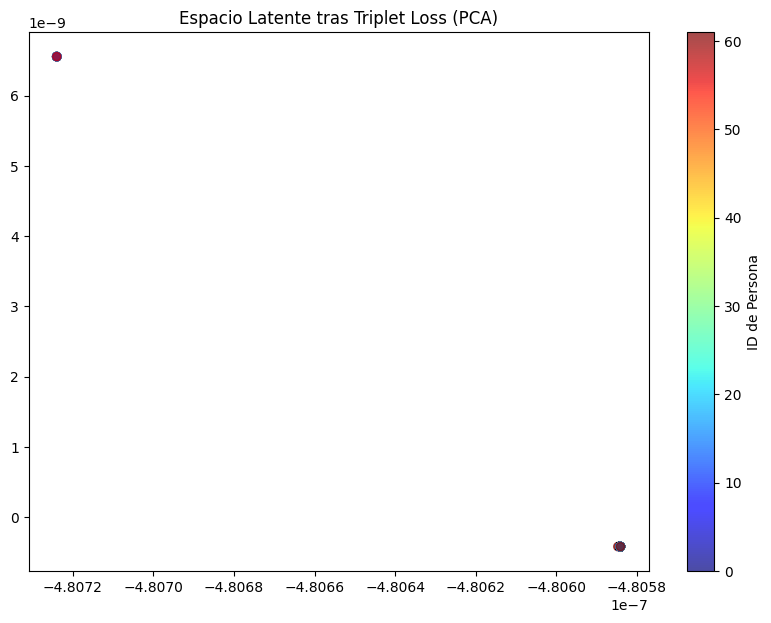

In [16]:
# Entrenar el modelo con tripletes (y_true no se usa, pasamos ceros dummy)
triplet_model.fit([A, P, N], np.zeros(len(A)), epochs=15, batch_size=32)

# Visualizar la mejora con los nuevos embeddings
embeddings_triplet = base_network.predict(X[:300])
emb2d_triplet = PCA(n_components=2).fit_transform(embeddings_triplet)

plt.figure(figsize=(10, 7))
plt.scatter(emb2d_triplet[:, 0], emb2d_triplet[:, 1], c=y[:300], cmap='jet', alpha=0.7)
plt.colorbar(label='ID de Persona')
plt.title("Espacio Latente tras Triplet Loss (PCA)")
plt.show()

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 726ms/step - accuracy: 0.4913 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 713ms/step - accuracy: 0.4909 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 719ms/step - accuracy: 0.4938 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 707ms/step - accuracy: 0.4916 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 712ms/step - accuracy: 0.4938 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 700ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 770ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 714ms/step - accuracy: 0.4988 - loss: 0

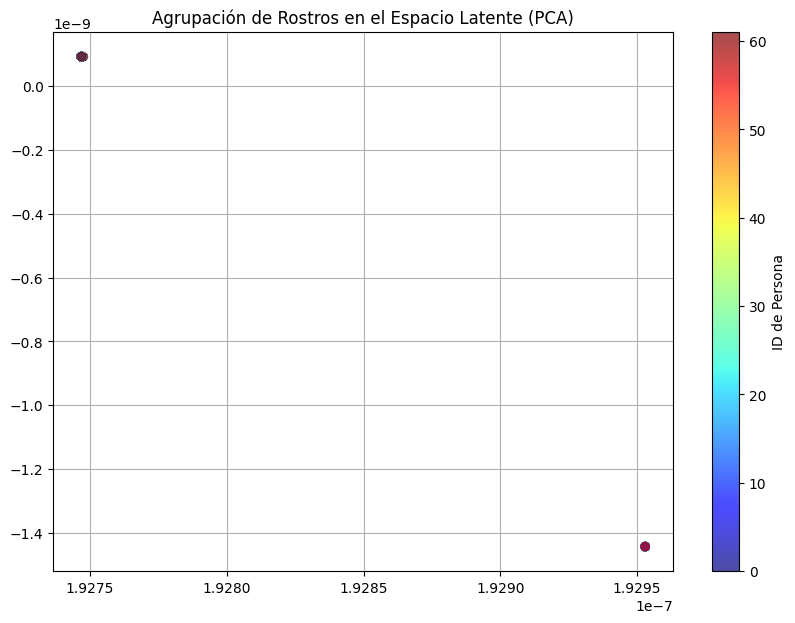

In [17]:
# Entrenar el modelo con los pares generados
history = siamese_model.fit([X1, X2], labels_pares, epochs=10, batch_size=32, validation_split=0.2)

# Visualización: Extraer embeddings de las imágenes originales
embeddings_test = base_network.predict(X[:300])
# Reducir a 2D para visualización
pca_viz = PCA(n_components=2)
emb2d_viz = pca_viz.fit_transform(embeddings_test)

plt.figure(figsize=(10, 7))
plt.scatter(emb2d_viz[:, 0], emb2d_viz[:, 1], c=y[:300], cmap='jet', alpha=0.7)
plt.colorbar(label='ID de Persona')
plt.title("Agrupación de Rostros en el Espacio Latente (PCA)")
plt.grid(True)
plt.show()